In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from pathlib import Path
import pickle

In [2]:
final_model = joblib.load(
    "../models/final_churn_model.pkl"
)

print(final_model)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=5,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)


In [3]:
X_test = pd.read_csv(
    "../data/processed/ml_X_test_final.csv"
)

y_test = pd.read_csv(
    "../data/processed/ml_y_test.csv"
).squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (1409, 53)
y_test shape: (1409,)


In [4]:
PROJECT_ROOT = Path.cwd().parent

MODEL_PATH = PROJECT_ROOT / "models" / "final_churn_model.pkl"
FEATURE_PATH = PROJECT_ROOT / "models" / "selected_features.pkl"
THRESHOLD_PATH = PROJECT_ROOT / "models" / "churn_threshold.pkl"

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "feature_engineered_data.csv"

In [5]:
print("Model:", MODEL_PATH)
print("Features:", FEATURE_PATH)
print("Threshold:", THRESHOLD_PATH)
print("Data:", DATA_PATH)

Model: /home/aximsoft/Downloads/Weekend_Task/AI Customer Intelligence Platform /models/final_churn_model.pkl
Features: /home/aximsoft/Downloads/Weekend_Task/AI Customer Intelligence Platform /models/selected_features.pkl
Threshold: /home/aximsoft/Downloads/Weekend_Task/AI Customer Intelligence Platform /models/churn_threshold.pkl
Data: /home/aximsoft/Downloads/Weekend_Task/AI Customer Intelligence Platform /data/processed/feature_engineered_data.csv


In [6]:
print("Model exists:", MODEL_PATH.exists())
print("Selected features exists:", FEATURE_PATH.exists())
print("Threshold exists:", THRESHOLD_PATH.exists())
print("Feature engineered data exists:", DATA_PATH.exists())

Model exists: True
Selected features exists: True
Threshold exists: True
Feature engineered data exists: True


In [7]:
final_model = joblib.load(MODEL_PATH)

In [8]:
final_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider

In [9]:
with open(FEATURE_PATH, "rb") as f:
    selected_features = pickle.load(f)

print(type(selected_features))
print("Number of selected features:", len(selected_features))
print(selected_features)

<class 'list'>
Number of selected features: 20
['MonthToMonthContract', 'ServiceRiskIndicator', 'tenure', 'InternetService_Fiber optic', 'NoOnlineSecurity', 'Contract_Two year', 'NoTechSupport', 'IsFiberCustomer', 'TotalCharges', 'ElectronicCheck', 'TenureGroup_New', 'IsNewCustomer', 'MonthlyCharges', 'ChargePerTenure', 'IsLongTermCustomer', 'PaymentMethod_Electronic check', 'TenureGroup_Long-term', 'Contract_One year', 'TechSupport_No internet service', 'OnlineBackup_No internet service']


In [10]:
with open(THRESHOLD_PATH, "rb") as f:
    churn_threshold = pickle.load(f)

print("Churn threshold:", churn_threshold)

Churn threshold: 0.5


In [11]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head())

Shape: (7043, 38)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... MonthlyChargeGroup  \
0  No phone service             DSL             No  ...                Low   
1                No             DSL            Yes  ...             Medium   
2                No             DSL            Yes  ...             Medium   
3  No phone service             DSL            Yes  ...             Medium   
4                No     Fiber optic             No  ...               High   

  TotalChargeGroup ChargePerTenu

In [12]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'IsNewCustomer', 'IsLongTermCustomer', 'NumberOfServices', 'OptionalServiceCount', 'HasInternetService', 'IsFiberCustomer', 'MonthlyChargeGroup', 'TotalChargeGroup', 'ChargePerTenure', 'HighValueCustomer', 'MonthToMonthContract', 'ElectronicCheck', 'NoTechSupport', 'NoOnlineSecurity', 'ServiceRiskIndicator', 'HighRiskCustomer']


In [13]:
customer_ids = df["customerID"].copy()

X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 36)
y shape: (7043,)


In [15]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded shape:", X_encoded.shape)

Encoded shape: (7043, 53)


In [16]:
X_encoded

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,IsNewCustomer,IsLongTermCustomer,NumberOfServices,OptionalServiceCount,HasInternetService,IsFiberCustomer,...,PaymentMethod_Mailed check,TenureGroup_Long-term,TenureGroup_Mid,TenureGroup_New,MonthlyChargeGroup_Low,MonthlyChargeGroup_Medium,MonthlyChargeGroup_Very High,TotalChargeGroup_Low,TotalChargeGroup_Medium,TotalChargeGroup_Very High
0,0,1,29.85,29.85,1,0,3,1,1,0,...,False,False,False,True,True,False,False,True,False,False
1,0,34,56.95,1889.50,0,0,4,2,1,0,...,True,False,True,False,False,True,False,False,False,False
2,0,2,53.85,108.15,1,0,4,2,1,0,...,True,False,False,True,False,True,False,True,False,False
3,0,45,42.30,1840.75,0,0,5,3,1,0,...,False,False,True,False,False,True,False,False,False,False
4,0,2,70.70,151.65,1,0,2,0,1,1,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,0,8,5,1,0,...,True,False,False,False,False,False,False,False,False,False
7039,0,72,103.20,7362.90,0,1,7,4,1,1,...,False,True,False,False,False,False,True,False,False,True
7040,0,11,29.60,346.45,1,0,3,1,1,0,...,False,False,False,True,True,False,False,True,False,False
7041,1,4,74.40,306.60,1,0,3,0,1,1,...,True,False,False,True,False,False,False,True,False,False


In [19]:
X_selected = X_encoded.reindex(
    columns=selected_features,
    fill_value=0
)

print("Selected feature shape:", X_selected.shape)
print("Expected features:", len(selected_features))
print("Actual features:", X_selected.shape[1])

Selected feature shape: (7043, 20)
Expected features: 20
Actual features: 20


In [20]:
sample_prediction = final_model.predict(X_selected.iloc[:5].reindex(columns=final_model.feature_names_in_, fill_value=0))

print("Predictions:")

print(sample_prediction)

Predictions:
[1 0 0 0 1]


In [21]:
sample_probability = final_model.predict_proba(
    X_selected.iloc[:5].reindex(columns=final_model.feature_names_in_, fill_value=0)
)[:, 1]

print("Churn probabilities:")
print(sample_probability)

Churn probabilities:
[0.58075552 0.32950118 0.42456474 0.30562263 0.73724862]


In [22]:
explainer = shap.TreeExplainer(final_model)

In [23]:
print(type(explainer))

<class 'shap.explainers._tree.TreeExplainer'>


In [ ]:
shap_values = explainer.shap_values(X_selected, check_additivity=False)

print(type(shap_values))

<class 'numpy.ndarray'>


In [25]:
if isinstance(shap_values, list):
    print("Number of SHAP outputs:", len(shap_values))
    for i, value in enumerate(shap_values):
        print(i, value.shape)
else:
    print("SHAP shape:", np.array(shap_values).shape)

SHAP shape: (7043, 20, 2)


In [26]:
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values

print("Final SHAP shape:", np.array(shap_values_churn).shape)

Final SHAP shape: (7043, 20, 2)


In [27]:
global_importance = pd.DataFrame({
    "Feature": X_selected.columns,
    # Slice [:, :, 1] for class 1, then mean over sample axis 0
    "Mean_Absolute_SHAP": np.abs(shap_values_churn[:, :, 1]).mean(axis=0)
})

global_importance = global_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

global_importance.head(20)

,Feature,Mean_Absolute_SHAP
16,TenureGroup_Long-term,0.044864
12,MonthlyCharges,0.044518
3,InternetService_Fiber optic,0.038251
1,ServiceRiskIndicator,0.033960
9,ElectronicCheck,0.032217
4,NoOnlineSecurity,0.027193
15,PaymentMethod_Electronic check,0.025902
14,IsLongTermCustomer,0.021832
18,TechSupport_No internet service,0.021116
0,MonthToMonthContract,0.017559


In [28]:
output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

In [29]:
global_importance.to_csv(
    output_dir / "shap_global_importance.csv",
    index=False
)

print("Saved:", output_dir / "shap_global_importance.csv")

Saved: /home/aximsoft/Downloads/Weekend_Task/AI Customer Intelligence Platform /data/processed/shap_global_importance.csv


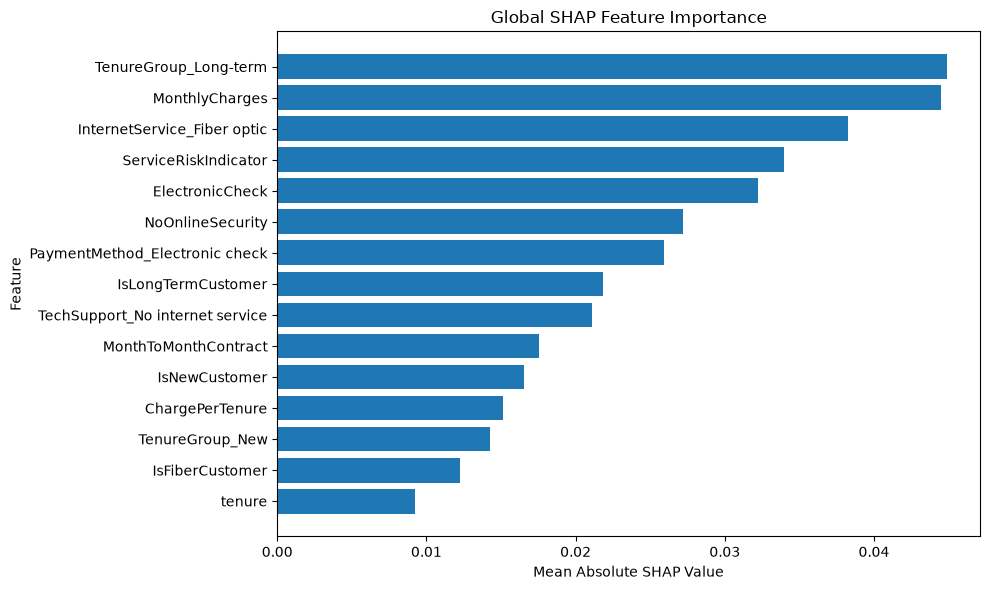

In [30]:
plt.figure(figsize=(10, 6))

shap_importance = global_importance.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.barh(
    shap_importance["Feature"],
    shap_importance["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")

plt.tight_layout()
plt.show()

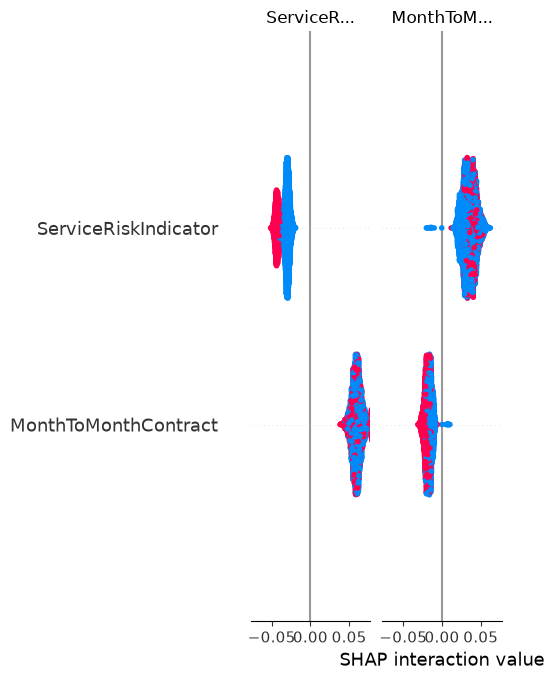

In [32]:
shap.summary_plot(
    shap_values_churn,
    X_selected,
    show=True
)

In [33]:
customer_id = customer_ids.iloc[0]

print("Customer ID:", customer_id)

Customer ID: 7590-VHVEG


In [34]:
customer_index = customer_ids[
    customer_ids == customer_id
].index[0]

print("Customer index:", customer_index)

Customer index: 0


In [35]:
customer_features = X_selected.loc[[customer_index]]

# Prediction:

customer_probability = final_model.predict_proba(
    customer_features.reindex(columns=final_model.feature_names_in_, fill_value=0)
)[0, 1]

customer_prediction = int(
    customer_probability >= churn_threshold
)

print("Customer ID:", customer_id)
print("Churn Probability:", customer_probability)
print("Prediction:", customer_prediction)

Customer ID: 7590-VHVEG
Churn Probability: 0.5807555160765269
Prediction: 1


In [36]:
customer_shap = shap_values_churn[
    customer_index
]


In [38]:
print(X_selected.shape)
print(customer_features.iloc[0].shape)
print(shap_values.shape)

(7043, 20)
(20,)
(7043, 20, 2)


In [69]:
temp = pd.DataFrame(shap_values[0])

In [71]:
temp_temp = temp[0]

shap_flat = temp_temp

In [54]:
shap_values[0]

array([[-5.88878832e-03,  5.88878832e-03],
       [ 4.20071755e-02, -4.20071755e-02],
       [-9.23577186e-03,  9.23577186e-03],
       [ 1.87713713e-02, -1.87713713e-02],
       [-1.94678953e-02,  1.94678953e-02],
       [-7.12212385e-03,  7.12212385e-03],
       [ 1.05074654e-03, -1.05074654e-03],
       [-1.19422694e-03,  1.19422694e-03],
       [-2.48462502e-03,  2.48462502e-03],
       [-3.23018648e-02,  3.23018648e-02],
       [-8.14006267e-03,  8.14006267e-03],
       [-3.77634618e-03,  3.77634618e-03],
       [-5.03597704e-02,  5.03597704e-02],
       [-1.71799202e-02,  1.71799202e-02],
       [ 2.35147137e-02, -2.35147137e-02],
       [-2.01829842e-02,  2.01829842e-02],
       [ 3.86572846e-02, -3.86572846e-02],
       [ 7.77826020e-04, -7.77826020e-04],
       [ 2.95974221e-05, -2.95974221e-05],
       [-1.05749386e-03,  1.05749386e-03]])

In [72]:
# Construct the DataFrame
customer_explanation = pd.DataFrame({
    "Feature": X_selected.columns,
    "Feature_Value": customer_features.iloc[0].values,
    "SHAP_Value": shap_flat
})

customer_explanation.sort_values(by="SHAP_Value", key=abs, ascending=False).head(10)

,Feature,Feature_Value,SHAP_Value
12,MonthlyCharges,29.85,-0.050360
1,ServiceRiskIndicator,1,0.042007
16,TenureGroup_Long-term,False,0.038657
9,ElectronicCheck,1,-0.032302
14,IsLongTermCustomer,0,0.023515
15,PaymentMethod_Electronic check,True,-0.020183
4,NoOnlineSecurity,1,-0.019468
3,InternetService_Fiber optic,False,0.018771
13,ChargePerTenure,29.85,-0.017180
2,tenure,1,-0.009236


In [73]:
customer_explanation["Absolute_SHAP"] = (
    customer_explanation["SHAP_Value"].abs()
)

customer_explanation = customer_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

customer_explanation.head(15)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
12,MonthlyCharges,29.85,-0.050360,0.050360
1,ServiceRiskIndicator,1,0.042007,0.042007
16,TenureGroup_Long-term,False,0.038657,0.038657
9,ElectronicCheck,1,-0.032302,0.032302
14,IsLongTermCustomer,0,0.023515,0.023515
15,PaymentMethod_Electronic check,True,-0.020183,0.020183
4,NoOnlineSecurity,1,-0.019468,0.019468
3,InternetService_Fiber optic,False,0.018771,0.018771
13,ChargePerTenure,29.85,-0.017180,0.017180
2,tenure,1,-0.009236,0.009236


In [84]:
positive_contributors = customer_explanation[
    customer_explanation["SHAP_Value"] > 0
].sort_values(
    "SHAP_Value",
    ascending=False
)

In [85]:
negative_contributors = customer_explanation[
    customer_explanation["SHAP_Value"] < 0
].sort_values(
    "SHAP_Value",
    ascending=True
)

In [86]:
print("Factors increasing churn:")
display(positive_contributors.head(10))

print("Factors reducing churn:")
display(negative_contributors.head(10))

Factors increasing churn:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
1,ServiceRiskIndicator,1,0.042007,0.042007
16,TenureGroup_Long-term,False,0.038657,0.038657
14,IsLongTermCustomer,0,0.023515,0.023515
3,InternetService_Fiber optic,False,0.018771,0.018771
6,NoTechSupport,1,0.001051,0.001051
17,Contract_One year,False,0.000778,0.000778
18,TechSupport_No internet service,False,0.000030,0.000030


Factors reducing churn:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
12,MonthlyCharges,29.85,-0.050360,0.050360
9,ElectronicCheck,1,-0.032302,0.032302
15,PaymentMethod_Electronic check,True,-0.020183,0.020183
4,NoOnlineSecurity,1,-0.019468,0.019468
13,ChargePerTenure,29.85,-0.017180,0.017180
2,tenure,1,-0.009236,0.009236
10,TenureGroup_New,True,-0.008140,0.008140
5,Contract_Two year,False,-0.007122,0.007122
0,MonthToMonthContract,1,-0.005889,0.005889
11,IsNewCustomer,1,-0.003776,0.003776


In [83]:
negative_contributors["Feature"]

12                      MonthlyCharges
9                      ElectronicCheck
15      PaymentMethod_Electronic check
4                     NoOnlineSecurity
13                     ChargePerTenure
2                               tenure
10                     TenureGroup_New
5                    Contract_Two year
0                 MonthToMonthContract
11                       IsNewCustomer
8                         TotalCharges
7                      IsFiberCustomer
19    OnlineBackup_No internet service
Name: Feature, dtype: str

In [89]:
positive_contributors["Feature"]

1                ServiceRiskIndicator
16              TenureGroup_Long-term
14                 IsLongTermCustomer
3         InternetService_Fiber optic
6                       NoTechSupport
17                  Contract_One year
18    TechSupport_No internet service
Name: Feature, dtype: str

In [90]:
customer_explanation.to_csv(
    output_dir / "customer_shap_explanation.csv",
    index=False
)